In [29]:
import cv2
import numpy as np
from pathlib import Path
from EvEye.utils.visualization.visualization import *
import matplotlib.pyplot as plt
from natsort import natsorted

In [30]:
root_path = Path(
    "/mnt/data2T/junyuan/eye-tracking/outputs/EventMasks/user1_left_session_1_0_1"
)

In [31]:
def get_masks(root_path):
    masks = []
    for file in root_path.iterdir():
        if file.suffix == ".png":
            if file.stem.split("_")[-1] == "mask":
                masks.append(file)
    return natsorted(masks)

In [32]:
def draw_ellipse(canvas, ellipse):
    """
    Draw the ellipse and its feature points on the given canvas.

    Parameters:
    canvas: Canvas to draw on
    ellipse: Ellipse parameters returned by cv2.fitEllipse
    """
    # Get ellipse parameters
    center = ellipse[0]  # Ellipse center (x, y)
    axes = ellipse[1]  # Major and minor axes (major axis, minor axis)
    angle = ellipse[2]  # Rotation angle

    # Draw the ellipse on the canvas
    cv2.ellipse(canvas, ellipse, (0, 255, 0), 1)  # White ellipse

    # Compute the major-axis endpoints
    long_axis_start = (
        int(center[0] - axes[0] / 2 * np.cos(np.radians(angle))),
        int(center[1] - axes[0] / 2 * np.sin(np.radians(angle))),
    )
    long_axis_end = (
        int(center[0] + axes[0] / 2 * np.cos(np.radians(angle))),
        int(center[1] + axes[0] / 2 * np.sin(np.radians(angle))),
    )

    # Draw the major axis
    cv2.line(canvas, long_axis_start, long_axis_end, (0, 255, 0), 1)  # Green major axis

    # Compute the minor-axis endpoints
    short_axis_start = (
        int(center[0] - axes[1] / 2 * np.sin(np.radians(angle))),
        int(center[1] + axes[1] / 2 * np.cos(np.radians(angle))),
    )
    short_axis_end = (
        int(center[0] + axes[1] / 2 * np.sin(np.radians(angle))),
        int(center[1] - axes[1] / 2 * np.cos(np.radians(angle))),
    )

    # Draw the minor axis
    cv2.line(canvas, short_axis_start, short_axis_end, (255, 255, 0), 1)  # Yellow minor axis

    # Draw the center point
    cv2.circle(
        canvas, (int(center[0]), int(center[1])), 2, (0, 0, 255), -1
    )  # Red center point

    # Print ellipse parameters with two decimal places
    print(
        f"Ellipse center: ({center[0]:.2f}, {center[1]:.2f}), Major axis: {axes[0]:.2f}, Minor axis: {axes[1]:.2f}, Rotation angle: {angle:.2f}"
    )

In [33]:
masks = natsorted(get_masks(root_path))
mask = natsorted(masks)[5]

In [35]:
raw_image = load_image(str(mask))[0]
gray_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2GRAY)
contours, _ = cv2.findContours(gray_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
canvas = np.zeros_like(raw_image)
for contour in contours:
    if len(contour) > 5:
        ellipse = cv2.fitEllipse(contour)
        draw_ellipse(canvas, ellipse)
        print(ellipse)
        print(type(ellipse))
        print(len(ellipse))

Ellipse center: (184.51, 139.14), Major axis: 41.00, Minor axis: 48.12, Rotation angle: 82.49
((184.5068359375, 139.13592529296875), (41.00020980834961, 48.12195587158203), 82.49444580078125)
<class 'tuple'>
3


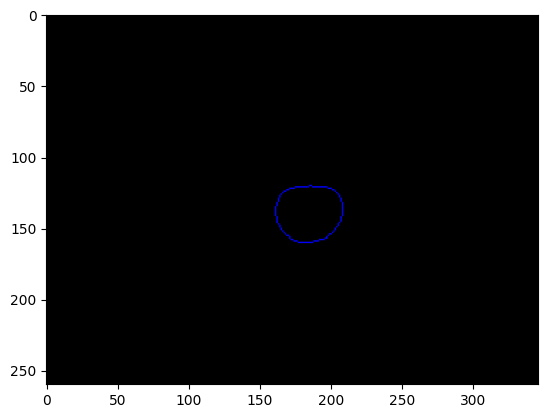

In [36]:
plt.imshow(raw_image)

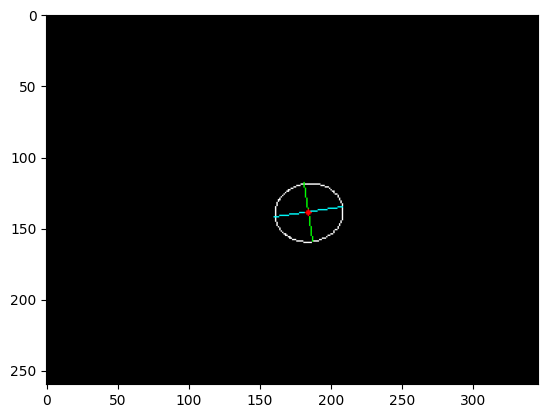

In [37]:
canvas = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
plt.imshow(canvas)

In [38]:
ellipse

((184.5068359375, 139.13592529296875),
 (41.00020980834961, 48.12195587158203),
 82.49444580078125)